# ***Class Imbalance Handling + Threshold Tuning***

In [ ]:
import numpy as np
import tensorflow as tf
import joblib
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, fbeta_score, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

baseline_model = tf.keras.models.load_model('../models/ann_churn_baseline.h5')

In [ ]:
import pandas as pd
X_test_processed = pd.read_csv('../data/proccessed/X_test_processed.csv')
X_train_processed = pd.read_csv('../data/proccessed/X_train_processed.csv')
y_test_processed = pd.read_csv('../data/proccessed/y_test_processed.csv')
y_train_processed = pd.read_csv('../data/proccessed/y_train_processed.csv')

label_encoder = joblib.load('../models/label_encoder.pkl')
scaler = joblib.load('../models/scaler.pkl')

In [11]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_processed['Exited']),
    y=y_train_processed['Exited']
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.6279434850863422), 1: np.float64(2.4539877300613497)}


In [12]:
from tensorflow.keras import layers, models, regularizers, initializers

def build_ann(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu',
                     kernel_initializer=initializers.HeNormal(seed=SEED),
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.30),

        layers.Dense(32, activation='relu',
                     kernel_initializer=initializers.HeNormal(seed=SEED),
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.20),

        layers.Dense(16, activation='relu',
                     kernel_initializer=initializers.HeNormal(seed=SEED)),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model_cw = build_ann(input_dim=X_train_processed.shape[1])

model_cw.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.AUC(name='auc')]
)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
checkpoint_cw = ModelCheckpoint('models/ann_churn_classweight.h5',
                                 monitor='val_auc', mode='max', save_best_only=True, verbose=1)

history_cw = model_cw.fit(
    X_train_processed, y_train_processed,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint_cw],
    verbose=1
)

Epoch 1/150
198/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5177 - auc: 0.6008 - loss: 0.9200 - precision: 0.2552 - recall: 0.6708
Epoch 1: val_auc improved from None to 0.77018, saving model to models/ann_churn_classweight.h5



Epoch 1: finished saving model to models/ann_churn_classweight.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5706 - auc: 0.6522 - loss: 0.8612 - precision: 0.2747 - recall: 0.6695 - val_accuracy: 0.6550 - val_auc: 0.7702 - val_loss: 0.7912 - val_precision: 0.3384 - val_recall: 0.7594 - learning_rate: 0.0010
Epoch 2/150
195/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6542 - auc: 0.7330 - loss: 0.7955 - precision: 0.3455 - recall: 0.7188
Epoch 2: val_auc improved from 0.77018 to 0.80758, saving model to models/ann_churn_classweight.h5



Epoch 2: finished saving model to models/ann_churn_classweight.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6631 - auc: 0.7456 - loss: 0.7753 - precision: 0.3463 - recall: 0.7275 - val_accuracy: 0.6956 - val_auc: 0.8076 - val_loss: 0.7379 - val_precision: 0.3721 - val_recall: 0.7594 - learning_rate: 0.0010
Epoch 3/150
197/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6826 - auc: 0.7622 - loss: 0.7589 - precision: 0.3691 - recall: 0.7170
Epoch 3: val_auc improved from 0.80758 to 0.82732, saving model to models/ann_churn_classweight.h5



Epoch 3: finished saving model to models/ann_churn_classweight.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6905 - auc: 0.7744 - loss: 0.7379 - precision: 0.3700 - recall: 0.7290 - val_accuracy: 0.7306 - val_auc: 0.8273 - val_loss: 0.6945 - val_precision: 0.4083 - val_recall: 0.7719 - learning_rate: 0.0010
Epoch 4/150
194/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6965 - auc: 0.7768 - loss: 0.7309 - precision: 0.3799 - recall: 0.7004
Epoch 4: val_auc improved from 0.82732 to 0.84120, saving model to models/ann_churn_classweight.h5



Epoch 4: finished saving model to models/ann_churn_classweight.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7080 - auc: 0.7903 - loss: 0.7104 - precision: 0.3863 - recall: 0.7252 - val_accuracy: 0.7412 - val_auc: 0.8412 - val_loss: 0.6702 - val_precision: 0.4232 - val_recall: 0.8094 - learning_rate: 0.0010
Epoch 5/150
195/200 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7136 - auc: 0.7924 - loss: 0.7051 - precision: 0.4009 - recall: 0.7291
Epoch 5: val_auc improved from 0.84120 to 0.84768, saving model to models/ann_churn_classweight.h5


...


Epoch 13: finished saving model to models/ann_churn_classweight.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7678 - auc: 0.8420 - loss: 0.5783 - precision: 0.4597 - recall: 0.7656 - val_accuracy: 0.7794 - val_auc: 0.8634 - val_loss: 0.5401 - val_precision: 0.4694 - val_recall: 0.7906 - learning_rate: 0.0010
Epoch 14/150
193/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7693 - auc: 0.8508 - loss: 0.5676 - precision: 0.4704 - recall: 0.7807
Epoch 14: val_auc improved from 0.86338 to 0.86478, saving model to models/ann_churn_classweight.h5



Epoch 14: finished saving model to models/ann_churn_classweight.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7694 - auc: 0.8493 - loss: 0.5629 - precision: 0.4620 - recall: 0.7710 - val_accuracy: 0.7756 - val_auc: 0.8648 - val_loss: 0.5388 - val_precision: 0.4644 - val_recall: 0.7937 - learning_rate: 0.0010
Epoch 15/150
198/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7563 - auc: 0.8387 - loss: 0.5779 - precision: 0.4519 - recall: 0.7460
Epoch 15: val_auc did not improve from 0.86478
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7625 - auc: 0.8425 - loss: 0.5667 - precision: 0.4527 - recall: 0.7664 - val_accuracy: 0.7731 - val_auc: 0.8633 - val_loss: 0.5372 - val_precision: 0.4608 - val_recall: 0.7906 - learning_rate: 0.0010
Epoch 16/150
195/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7667 - auc: 0.8440 - loss: 0.5675 - precision: 0.4659 - recall: 0.7442
Epoch 16: val_auc did not improve from 0.86478
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accurac


Epoch 19: finished saving model to models/ann_churn_classweight.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7741 - auc: 0.8548 - loss: 0.5355 - precision: 0.4685 - recall: 0.7733 - val_accuracy: 0.7850 - val_auc: 0.8657 - val_loss: 0.5132 - val_precision: 0.4775 - val_recall: 0.7969 - learning_rate: 0.0010
Epoch 20/150
185/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7642 - auc: 0.8554 - loss: 0.5372 - precision: 0.4638 - recall: 0.7700
Epoch 20: val_auc improved from 0.86569 to 0.86866, saving model to models/ann_churn_classweight.h5



Epoch 20: finished saving model to models/ann_churn_classweight.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7672 - auc: 0.8532 - loss: 0.5342 - precision: 0.4588 - recall: 0.7656 - val_accuracy: 0.7850 - val_auc: 0.8687 - val_loss: 0.5013 - val_precision: 0.4773 - val_recall: 0.7875 - learning_rate: 0.0010
Epoch 21/150
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7803 - auc: 0.8597 - loss: 0.5282 - precision: 0.4861 - recall: 0.7749
Epoch 21: val_auc did not improve from 0.86866
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7763 - auc: 0.8547 - loss: 0.5293 - precision: 0.4714 - recall: 0.7687 - val_accuracy: 0.7825 - val_auc: 0.8670 - val_loss: 0.5079 - val_precision: 0.4739 - val_recall: 0.7937 - learning_rate: 0.0010
Epoch 22/150
192/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7749 - auc: 0.8605 - loss: 0.5233 - precision: 0.4789 - recall: 0.7730
Epoch 22: val_auc did not improve from 0.86866
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accurac


Epoch 26: finished saving model to models/ann_churn_classweight.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7830 - auc: 0.8639 - loss: 0.5057 - precision: 0.4814 - recall: 0.7802 - val_accuracy: 0.7825 - val_auc: 0.8700 - val_loss: 0.4854 - val_precision: 0.4739 - val_recall: 0.7937 - learning_rate: 0.0010
Epoch 27/150
190/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7697 - auc: 0.8653 - loss: 0.5065 - precision: 0.4709 - recall: 0.7737
Epoch 27: val_auc did not improve from 0.86997
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7748 - auc: 0.8600 - loss: 0.5088 - precision: 0.4695 - recall: 0.7695 - val_accuracy: 0.7750 - val_auc: 0.8691 - val_loss: 0.4996 - val_precision: 0.4635 - val_recall: 0.7937 - learning_rate: 0.0010
Epoch 28/150
197/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7864 - auc: 0.8712 - loss: 0.4963 - precision: 0.4948 - recall: 0.7949
Epoch 28: val_auc did not improve from 0.86997
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accurac

In [26]:
y_pred_prob_cw = model_cw.predict(X_test_processed).ravel()
y_pred_cw = (y_pred_prob_cw >= 0.16).astype(int)

print("=== Class-Weighted Model (threshold=0.16 ===")
print(classification_report(y_test_processed, y_pred_cw))
print("ROC-AUC:", roc_auc_score(y_test_processed, y_pred_prob_cw))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
=== Class-Weighted Model (threshold=0.16 ===
              precision    recall  f1-score   support

           0       0.96      0.46      0.63      1593
           1       0.31      0.93      0.46       407

    accuracy                           0.56      2000
   macro avg       0.64      0.70      0.54      2000
weighted avg       0.83      0.56      0.59      2000

ROC-AUC: 0.8537551418907352


In [15]:
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, thresholds = precision_recall_curve(y_test_processed, y_pred_prob_cw)

f2_scores = []
for p, r in zip(precision_vals[:-1], recall_vals[:-1]):
    if p + r == 0:
        f2_scores.append(0)
    else:
        f2 = (5 * p * r) / (4 * p + r)
        f2_scores.append(f2)

f2_scores = np.array(f2_scores)
best_idx = np.argmax(f2_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold (max F2): {best_threshold:.3f}")
print(f"At this threshold -> Precision: {precision_vals[best_idx]:.3f}, Recall: {recall_vals[best_idx]:.3f}, F2: {f2_scores[best_idx]:.3f}")

Best threshold (max F2): 0.371
At this threshold -> Precision: 0.411, Recall: 0.835, F2: 0.692


=== Class-Weighted Model @ Tuned Threshold (0.371) ===
              precision    recall  f1-score   support

           0       0.94      0.69      0.80      1593
           1       0.41      0.84      0.55       407

    accuracy                           0.72      2000
   macro avg       0.68      0.76      0.67      2000
weighted avg       0.83      0.72      0.75      2000



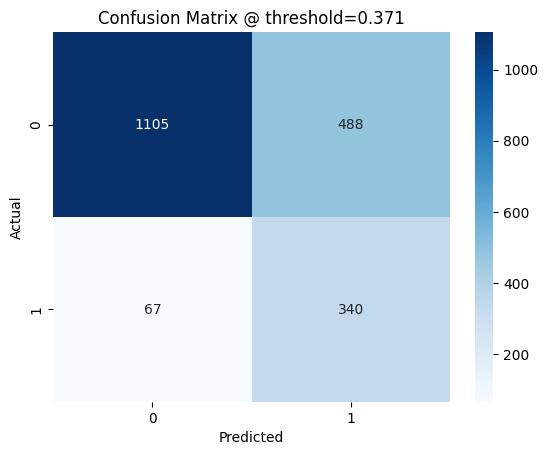

In [16]:
y_pred_tuned = (y_pred_prob_cw >= best_threshold).astype(int)

print(f"=== Class-Weighted Model @ Tuned Threshold ({best_threshold:.3f}) ===")
print(classification_report(y_test_processed, y_pred_tuned))

cm_tuned = confusion_matrix(y_test_processed, y_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix @ threshold={best_threshold:.3f}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
 
COST_FN = 500   
COST_FP = 50     
thresholds_to_test = np.arange(0.05, 0.95, 0.01)
costs = []

for thr in thresholds_to_test:
    y_pred_thr = (y_pred_prob_cw >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_processed, y_pred_thr).ravel()
    total_cost = (fn * COST_FN) + (fp * COST_FP)
    costs.append(total_cost)

costs = np.array(costs)
best_cost_idx = np.argmin(costs)
best_cost_threshold = thresholds_to_test[best_cost_idx]

print(f"Cost-optimal threshold: {best_cost_threshold:.3f}")
print(f"Minimum expected cost: ${costs[best_cost_idx]:,.0f}")

# Compare against default 0.5 for reference
default_pred = (y_pred_prob_cw >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test_processed, default_pred).ravel()
default_cost = (fn * COST_FN) + (fp * COST_FP)
print(f"Cost at default threshold (0.5): ${default_cost:,.0f}")
print(f"Savings by using cost-optimal threshold: ${default_cost - costs[best_cost_idx]:,.0f}")

Cost-optimal threshold: 0.160
Minimum expected cost: $56,800
Cost at default threshold (0.5): $64,500
Savings by using cost-optimal threshold: $7,700


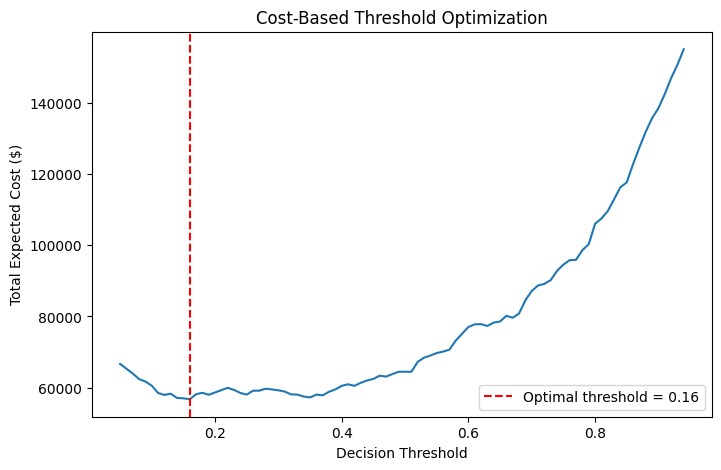

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(thresholds_to_test, costs)
plt.axvline(best_cost_threshold, color='red', linestyle='--',
            label=f'Optimal threshold = {best_cost_threshold:.2f}')
plt.xlabel('Decision Threshold')
plt.ylabel('Total Expected Cost ($)')
plt.title('Cost-Based Threshold Optimization')
plt.legend()
plt.show()

In [ ]:
def get_metrics(y_true, y_pred, y_prob, label):
    return {
        'Model': label,
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

# Baseline (Notebook 05) dobara predict
y_pred_prob_base = baseline_model.predict(X_test_processed).ravel()
y_pred_base = (y_pred_prob_base >= 0.5).astype(int)

results = [
    get_metrics(y_test_processed, y_pred_base, y_pred_prob_base, 'Baseline (thr=0.5)'),
    get_metrics(y_test_processed, y_pred_cw, y_pred_prob_cw, 'Class-Weighted (thr=0.5)'),
    get_metrics(y_test_processed, y_pred_tuned, y_pred_prob_cw, f'Class-Weighted (thr={best_threshold:.2f})'),
]

comparison_df = pd.DataFrame(results)
print(comparison_df)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
                       Model  Precision    Recall        F1   ROC-AUC
0         Baseline (thr=0.5)   0.747440  0.538084  0.625714  0.858015
1   Class-Weighted (thr=0.5)   0.472097  0.769042  0.585047  0.853755
2  Class-Weighted (thr=0.37)   0.410628  0.835381  0.550607  0.853755


In [ ]:
def build_ann(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu',
                     kernel_initializer=initializers.HeNormal(seed=SEED),
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.30),

        layers.Dense(32, activation='relu',
                     kernel_initializer=initializers.HeNormal(seed=SEED),
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.20),

        layers.Dense(16, activation='relu',
                     kernel_initializer=initializers.HeNormal(seed=SEED)),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall'),
                 tf.keras.metrics.AUC(name='auc')]
    )
    return model

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

fold_results = []
fold_models = []       # har fold ka model save karenge (ensemble ke liye bhi kaam aa sakta hai)
oof_probs = np.zeros(len(y_train_processed))   # out-of-fold predictions — poore dataset ke liye

X_array = X_train_processed.values if hasattr(X_train_processed, 'values') else X_train_processed
y_array = np.array(y_train_processed)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_array, y_array), 1):
    print(f"\n===== Fold {fold}/5 =====")

    X_tr, X_val = X_array[train_idx], X_array[val_idx]
    y_tr, y_val = y_array[train_idx], y_array[val_idx]

    fold_scaler = StandardScaler()
    X_tr_scaled = fold_scaler.fit_transform(X_tr)
    X_val_scaled = fold_scaler.transform(X_val)

    class_weights = compute_class_weight('balanced', classes=np.unique(y_tr.ravel()), y=y_tr.ravel())
    class_weight_dict = {i: w for i, w in enumerate(class_weights)}

    model = build_ann(input_dim=X_tr_scaled.shape[1])

    early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0)

    model.fit(
        X_tr_scaled, y_tr,
        validation_data=(X_val_scaled, y_val),
        epochs=150,
        batch_size=32,
        class_weight=class_weight_dict,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    val_probs = model.predict(X_val_scaled, verbose=0).ravel()
    oof_probs[val_idx] = val_probs
    val_preds = (val_probs >= 0.5).astype(int)

    fold_results.append({
        'Fold': fold,
        'Precision': precision_score(y_val, val_preds),
        'Recall': recall_score(y_val, val_preds),
        'F1': f1_score(y_val, val_preds),
        'ROC-AUC': roc_auc_score(y_val, val_probs)
    })
    fold_models.append(model)

    print(f"Fold {fold} -> Recall: {fold_results[-1]['Recall']:.3f}, "
          f"ROC-AUC: {fold_results[-1]['ROC-AUC']:.3f}")


===== Fold 1/5 =====
Fold 1 -> Recall: 0.752, ROC-AUC: 0.846

===== Fold 2/5 =====
Fold 2 -> Recall: 0.779, ROC-AUC: 0.871

===== Fold 3/5 =====
Fold 3 -> Recall: 0.736, ROC-AUC: 0.864

===== Fold 4/5 =====
Fold 4 -> Recall: 0.666, ROC-AUC: 0.826

===== Fold 5/5 =====
Fold 5 -> Recall: 0.733, ROC-AUC: 0.840


In [ ]:
cv_df = pd.DataFrame(fold_results)
print(cv_df)

print("\n=== Cross-Validation Summary (Mean ± Std) ===")
for metric in ['Precision', 'Recall', 'F1', 'ROC-AUC']:
    mean_val = cv_df[metric].mean()
    std_val = cv_df[metric].std()
    print(f"{metric}: {mean_val:.3f} ± {std_val:.3f}")

cv_df.to_csv('reports/cross_validation_results.csv', index=False)

   Fold  Precision    Recall        F1   ROC-AUC
0     1   0.482283  0.751534  0.587530  0.845522
1     2   0.508000  0.779141  0.615012  0.870593
2     3   0.520607  0.736196  0.609911  0.863921
3     4   0.472767  0.665644  0.552866  0.826461
4     5   0.467710  0.733129  0.571087  0.839528

=== Cross-Validation Summary (Mean ± Std) ===
Precision: 0.490 ± 0.023
Recall: 0.733 ± 0.042
F1: 0.587 ± 0.026
ROC-AUC: 0.849 ± 0.018


In [ ]:

CAPACITY = 500

risk_df = pd.DataFrame({
    'true_label': y_array.ravel(),
    'churn_probability': oof_probs
}).sort_values('churn_probability', ascending=False).reset_index(drop=True)

top_k = risk_df.head(CAPACITY)

captured_churners = top_k['true_label'].sum()
total_churners = y_array.sum()
capture_rate = captured_churners / total_churners

print(f"Capacity: {CAPACITY} customers")
print(f"Actual churners captured in top {CAPACITY}: {captured_churners} / {total_churners}")
print(f"Capture Rate (Recall@{CAPACITY}): {capture_rate:.1%}")
print(f"Precision@{CAPACITY}: {captured_churners / CAPACITY:.1%}")

Capacity: 500 customers
Actual churners captured in top 500: 441 / 1630
Capture Rate (Recall@500): 27.1%
Precision@500: 88.2%


In [ ]:
capacities = [200, 300, 500, 700, 1000]
capacity_results = []

for cap in capacities:
    top_k_temp = risk_df.head(cap)
    captured = top_k_temp['true_label'].sum()
    capacity_results.append({
        'Capacity': cap,
        'Churners_Captured': int(captured),
        'Total_Churners': int(total_churners),
        'Recall@K': captured / total_churners,
        'Precision@K': captured / cap
    })

capacity_df = pd.DataFrame(capacity_results)
print(capacity_df)

   Capacity  Churners_Captured  Total_Churners  Recall@K  Precision@K
0       200                187            1630  0.114724     0.935000
1       300                277            1630  0.169939     0.923333
2       500                441            1630  0.270552     0.882000
3       700                574            1630  0.352147     0.820000
4      1000                736            1630  0.451534     0.736000


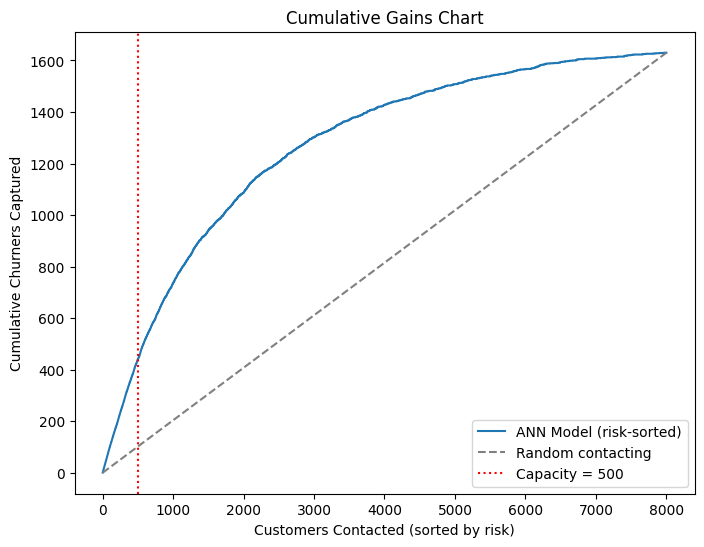

In [ ]:
risk_df['cumulative_churners'] = risk_df['true_label'].cumsum()
risk_df['customers_contacted'] = np.arange(1, len(risk_df) + 1)
risk_df['random_baseline'] = risk_df['customers_contacted'] * (total_churners / len(risk_df))

plt.figure(figsize=(8, 6))
plt.plot(risk_df['customers_contacted'], risk_df['cumulative_churners'], label='ANN Model (risk-sorted)')
plt.plot(risk_df['customers_contacted'], risk_df['random_baseline'], linestyle='--', color='gray', label='Random contacting')
plt.axvline(CAPACITY, color='red', linestyle=':', label=f'Capacity = {CAPACITY}')
plt.xlabel('Customers Contacted (sorted by risk)')
plt.ylabel('Cumulative Churners Captured')
plt.title('Cumulative Gains Chart')
plt.legend()
plt.savefig('reports/figures/cumulative_gains_chart.png')
plt.show()

In [ ]:
# Ab final deployment model poore dataset par train karein (max data use karne ke liye)
final_scaler = StandardScaler()
X_full_scaled = final_scaler.fit_transform(X_array)

class_weights_full = compute_class_weight('balanced', classes=np.unique(y_array.ravel()), y=y_array.ravel())
class_weight_dict_full = {i: w for i, w in enumerate(class_weights_full)}

final_model = build_ann(input_dim=X_full_scaled.shape[1])

early_stop = EarlyStopping(monitor='loss', patience=15, restore_best_weights=True, verbose=1)

history = final_model.fit(
    X_full_scaled, y_array,
    epochs=150,
    batch_size=32,
    class_weight=class_weight_dict_full,
    callbacks=[early_stop],
    verbose=1
)

final_model.save('models/ann_churn_production.h5')
joblib.dump(final_scaler, 'models/final_scaler.pkl')
joblib.dump(CAPACITY, 'models/business_capacity.pkl')

print("Final production model, scaler, and capacity setting saved.")

Epoch 1/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6047 - auc: 0.6623 - loss: 0.8488 - precision: 0.2917 - recall: 0.6583
Epoch 2/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6599 - auc: 0.7452 - loss: 0.7709 - precision: 0.3411 - recall: 0.7184
Epoch 3/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6969 - auc: 0.7851 - loss: 0.7209 - precision: 0.3762 - recall: 0.7411
Epoch 4/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7119 - auc: 0.7981 - loss: 0.6948 - precision: 0.3902 - recall: 0.7362
Epoch 5/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7309 - auc: 0.8112 - loss: 0.6679 - precision: 0.4107 - recall: 0.7380
Epoch 6/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7349 - auc: 0.8176 - loss: 0.6492 - precision: 0.4156 - recall: 0.7417
Epoch 7/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7372 - auc: 0.8177 - loss: 0.6404 - precision: 0.4180 - recall: 0.7380
Epoch 8/150
250/250 ━━━━━━━━━━━━━

Final production model, scaler, and capacity setting saved.


### Training History Visualization
Let's visualize the training and validation metrics (loss, accuracy, AUC, precision, recall) over epochs to understand the model's learning process.

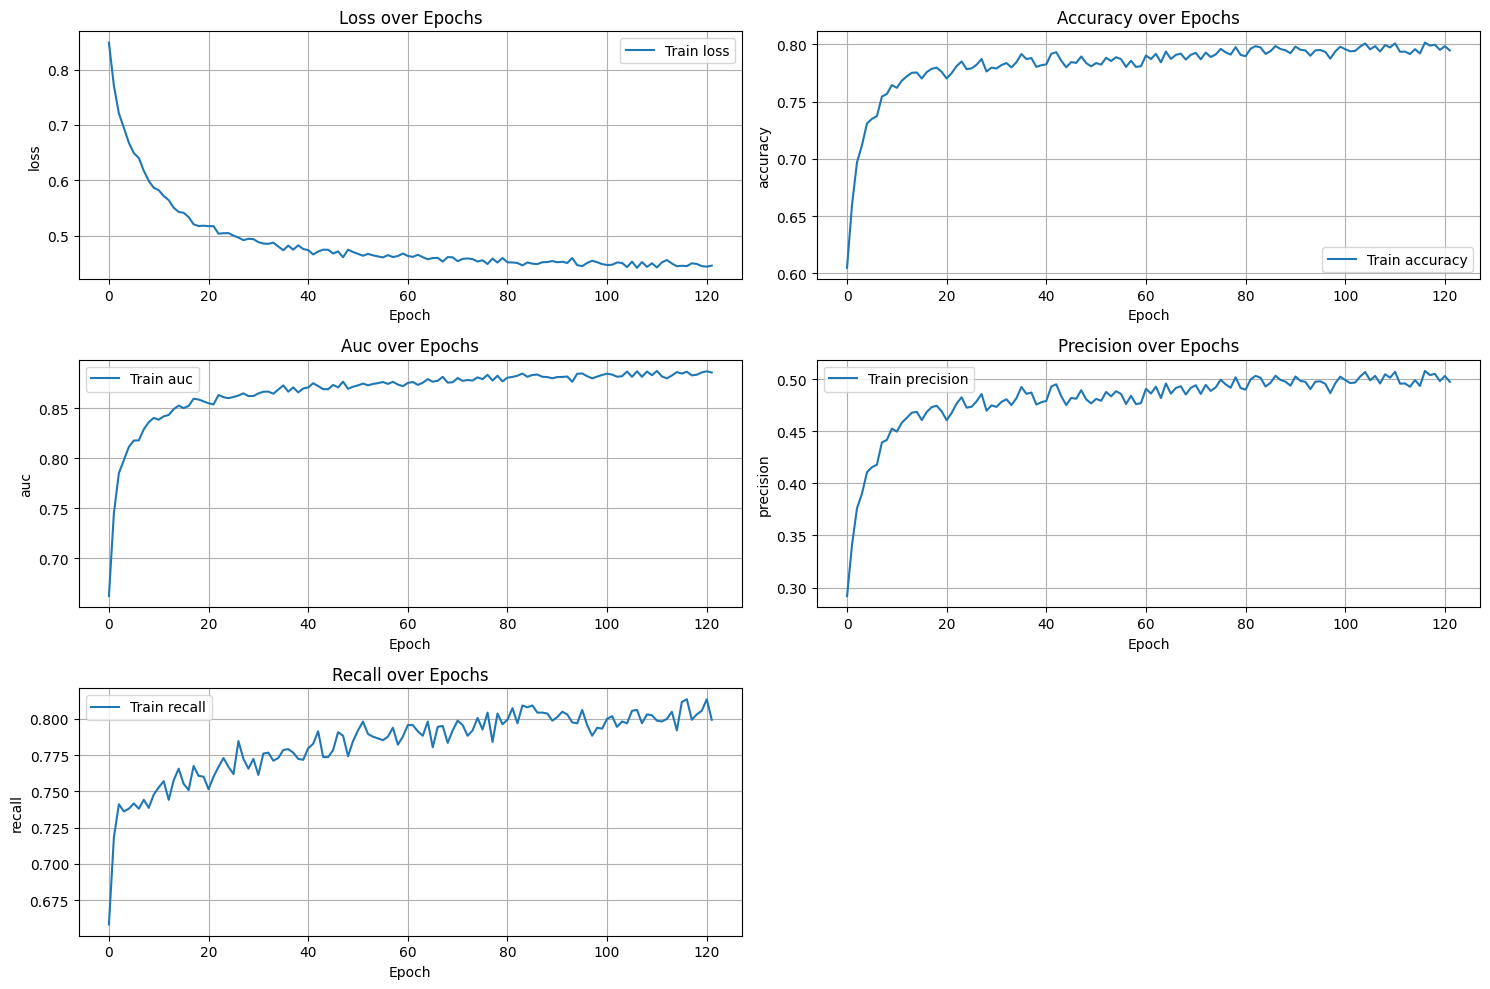

In [43]:
def plot_history(history):
    metrics = ['loss', 'accuracy', 'auc', 'precision', 'recall']
    plt.figure(figsize=(15, 10))

    for i, metric in enumerate(metrics):
        plt.subplot(3, 2, i + 1)
        plt.plot(history.history[metric], label=f'Train {metric}')

        # Check if validation metric exists before plotting
        val_metric_key = f'val_{metric}'
        if val_metric_key in history.history:
            plt.plot(history.history[val_metric_key], label=f'Validation {metric}')

        plt.title(f'{metric.capitalize()} over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel(metric)
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.show()

plot_history(history)